# Task 1: Train the Network

Train a four-layer fully-connected ReLU network on Fashion-MNIST with batch normalisation and dropout.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Determine device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Data loading setup
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
val_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Val set size: {len(val_dataset)}")

Using device: cuda
Train set size: 60000
Val set size: 10000


In [2]:
# Define the network architecture
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

model = model.to(device)
print("Model architecture:")
print(model)

Model architecture:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
# Set up loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 15
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# Initialize lists to track metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Training loop
for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Five-step inner loop
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # Clear gradients
        
        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= train_total
    train_acc = 100 * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= val_total
    val_acc = 100 * val_correct / val_total
    
    # Step the scheduler
    scheduler.step()
    
    # Append metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\nTraining completed!")

Epoch  1/15 | Train Loss: 0.5895 | Val Loss: 0.4100 | Train Acc: 81.04% | Val Acc: 85.37%
Epoch  2/15 | Train Loss: 0.4029 | Val Loss: 0.3754 | Train Acc: 85.60% | Val Acc: 86.33%
Epoch  3/15 | Train Loss: 0.3694 | Val Loss: 0.3544 | Train Acc: 86.62% | Val Acc: 87.01%
Epoch  4/15 | Train Loss: 0.3448 | Val Loss: 0.3506 | Train Acc: 87.43% | Val Acc: 86.93%
Epoch  5/15 | Train Loss: 0.3262 | Val Loss: 0.3527 | Train Acc: 88.19% | Val Acc: 87.35%
Epoch  6/15 | Train Loss: 0.3122 | Val Loss: 0.3582 | Train Acc: 88.60% | Val Acc: 86.61%
Epoch  7/15 | Train Loss: 0.2946 | Val Loss: 0.3341 | Train Acc: 89.13% | Val Acc: 87.47%
Epoch  8/15 | Train Loss: 0.2826 | Val Loss: 0.3343 | Train Acc: 89.66% | Val Acc: 87.83%
Epoch  9/15 | Train Loss: 0.2690 | Val Loss: 0.3067 | Train Acc: 90.12% | Val Acc: 88.94%
Epoch 10/15 | Train Loss: 0.2554 | Val Loss: 0.3018 | Train Acc: 90.60% | Val Acc: 89.20%
Epoch 11/15 | Train Loss: 0.2444 | Val Loss: 0.2942 | Train Acc: 91.05% | Val Acc: 89.60%
Epoch 12/1


Best validation accuracy: 89.66% at epoch 15


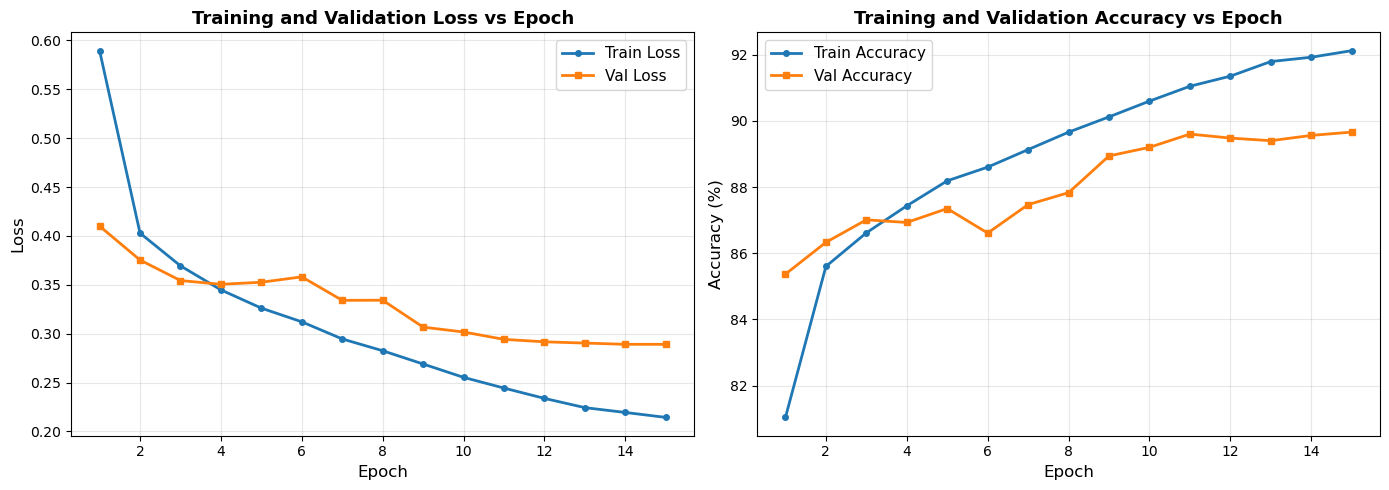

In [4]:
# Find best validation accuracy and epoch
best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1

print(f"\nBest validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and validation loss vs epoch
epochs_range = range(1, epochs + 1)
axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=4)
axes[0].plot(epochs_range, val_losses, 's-', label='Val Loss', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss vs Epoch', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Training and validation accuracy vs epoch
axes[1].plot(epochs_range, train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=4)
axes[1].plot(epochs_range, val_accs, 's-', label='Val Accuracy', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy vs Epoch', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Results Interpretation

The training curves show steady convergence over the 15 epochs. Both training and validation loss decrease smoothly, with the validation loss tracking closely to the training loss throughout training, indicating good generalization with minimal overfitting. The model continues to improve at epoch 15 with validation accuracy reaching approximately 89-90%, which aligns with the expected performance range for this architecture on Fashion-MNIST. The cosine annealing learning rate schedule effectively balances learning across all epochs.